This notebook performs an Exploratory Data Analysis (EDA) on the 2025 New York City 311 service requests dataset. The 311 system serves as the primary channel for New Yorkers to report non-emergency civic issues, ranging from noise complaints and infrastructure damage to housing violations. By analyzing this data, we aim to uncover seasonal trends, operational bottlenecks, and geographic hotspots of citizen concerns throughout 2025.

Here you can Dowload the Data. If you already have the data make sure its named "nyc311_2025.csv".

In [53]:
import os
import requests

# Downloads the data only if the file does not exist locally
url = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv"
params = {
    "$where": "created_date >= '2025-01-01T00:00:00' AND created_date < '2026-01-01T00:00:00'",
    "$limit": 5000000,
}
filename = "nyc311_2025.csv"

if not os.path.exists(filename):
    print("Downloading data...")
    r = requests.get(url, params=params)
    with open(filename, "wb") as f:
        f.write(r.content)
    print("done")
else:
    print("Data already exists locally. Skipping download.")

Data already exists locally. Skipping download.


**Auditing**

For the start, i will audit and clean the data to make sure all the information is in the form and scope of what we expect.

Before loading the full dataset, I work with a subset of the rows to keep memory usage low. I use this subset for two things: getting familiar with what each column looks like, and measuring how complete each column is (the share of missing values). Missingness is stable across the dataset, so a subset is enough to decide which columns are too sparse to keep. The value counts shown here are just to illustrate the columns — I don't draw conclusions from them, and any distribution I actually rely on later is recomputed on the full data

In [54]:
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv("nyc311_2025.csv", nrows=50000)
df.shape

/tmp/ipykernel_3161/3391233020.py:5: DtypeWarning: Columns (0: taxi_company_borough, 1: bridge_highway_direction) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("nyc311_2025.csv", nrows=50000)


(50000, 44)

In [55]:
df.head()

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,...,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,67351762,2025-12-31T23:59:28.000,2026-01-01T00:40:32.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,NaN,Residential Building/House,10029.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.792141,-73.950097,POINT (-73.950097072847 40.792140506424)
1,67344624,2025-12-31T23:59:23.000,2026-01-01T01:03:42.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,NaN,Residential Building/House,10031.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.825137,-73.949447,POINT (-73.949447237231 40.82513729001)
2,67346873,2025-12-31T23:59:21.000,2026-01-01T00:58:13.000,NYPD,New York City Police Department,Blocked Driveway,Partial Access,NaN,Street/Sidewalk,11234.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.619995,-73.921167,POINT (-73.921167390534 40.619994693785)
3,67353004,2025-12-31T23:59:20.000,2026-01-01T00:57:31.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,NaN,Residential Building/House,11235.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.591542,-73.955979,POINT (-73.955979130812 40.591541524842)
4,67350526,2025-12-31T23:59:12.000,2026-01-01T00:41:16.000,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,NaN,Store/Commercial,10031.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.822593,-73.949525,POINT (-73.949525045155 40.822592971648)


**Collumns**

Now lets get familiar with the most important columns for the analisys and plots.

*Unique Key*

Unique identifier of a Service Request (SR) in the open data set

In [56]:
df['unique_key'].sample(3)

19430    67327927
34311    67323080
12238    67333704
Name: unique_key, dtype: int64

*Created date and Closed date*

this as the name says, shows the date and time of the request (should be mandatory) and the date and time of when the request was closed (optional).

In [57]:
print(df['created_date'].sample(2))
print(df['closed_date'].sample(2))

44747    2025-12-27T00:11:12.000
8713     2025-12-31T00:05:09.000
Name: created_date, dtype: str
14351    2026-01-02T14:51:10.000
22209    2026-01-01T02:06:45.000
Name: closed_date, dtype: str


*Agency and Agency Name*

this is the Acronym or Full Agency Name of responding City Government Agency, each one has its own match.


In [58]:
print(df['agency'].unique())
print(df['agency_name'].unique())

<ArrowStringArray>
[ 'NYPD',   'TLC',   'HPD',   'DOB',   'DOT',  'DSNY',  'DCWP',   'DEP',
   'DPR',   'EDC', 'DOHMH',   'OOS',   'DHS',   'DOE',   'OTI']
Length: 15, dtype: str
<ArrowStringArray>
[                   'New York City Police Department',
                      'Taxi and Limousine Commission',
 'Department of Housing Preservation and Development',
                            'Department of Buildings',
                       'Department of Transportation',
                           'Department of Sanitation',
       'Department of Consumer and Worker Protection',
             'Department of Environmental Protection',
                 'Department of Parks and Recreation',
                   'Economic Development Corporation',
            'Department of Health and Mental Hygiene',
                              'Office of the Sheriff',
                    'Department of Homeless Services',
                            'Department of Education',
                'Office of Techn

*City and Borough*

this is the biggest generalization of the location of the requirement. Borough is more general while City is more specific and unreliable, for example in City, Manhattan in double counted in NEW YORK and MANHATTAN while also dividing into regions without a solid defition.

In [59]:
print(df['city'].value_counts().head())
print(df['borough'].value_counts().head())

city
BROOKLYN         14859
BRONX            11076
NEW YORK          9010
STATEN ISLAND     1840
JAMAICA           1284
Name: count, dtype: int64
borough
BROOKLYN         15259
QUEENS           11746
BRONX            11255
MANHATTAN         9783
STATEN ISLAND     1929
Name: count, dtype: int64


*Status*

status is a simple short string that shows the Progress of the request.
Since the data is from 2025 you can expect correctly that most are Closed. But there are other values that appear frequently, like In Progress, Open, Pending...

In [60]:
df['status'].value_counts()

status
Closed         48990
In Progress      622
Open             194
Assigned         107
Pending           58
Started           28
Unspecified        1
Name: count, dtype: int64

*Complaint type and Descriptor*

Those are the fisrt and second level of Hierarchy describing the problem, Complaint type is less categorized and easier to deal with

In [61]:
print(df['complaint_type'].value_counts()[1:4])
print(df['descriptor'].value_counts()[1:4])


complaint_type
Illegal Parking        6667
Noise - Residential    5249
Blocked Driveway       2691
Name: count, dtype: int64
descriptor
APARTMENT ONLY      4034
Loud Music/Party    3157
Banging/Pounding    2688
Name: count, dtype: int64


Analysing Columns Nan ratio in the subset.

In [62]:
df.isna().mean() * 100

unique_key                         0.000
created_date                       0.000
closed_date                        1.792
agency                             0.000
agency_name                        0.000
complaint_type                     0.000
descriptor                         1.168
descriptor_2                      49.492
location_type                     10.510
incident_zip                       0.852
incident_address                   3.522
street_name                        3.522
cross_street_1                    43.878
cross_street_2                    43.854
intersection_street_1             45.704
intersection_street_2             45.662
address_type                       0.474
city                               3.266
landmark                          51.514
facility_type                     99.824
status                             0.000
due_date                          99.712
resolution_description             1.804
resolution_action_updated_date     1.086
community_board 

**Cleaning**

Since this the dull DataSet is very specified and Heavy, with over 3 million rows and 44 collumns, i took the decision of only keeping the columns that are essential to the Analisys, dropping the ones that have a high Nan ratio and or are redundant considering there is another column that exemplifies the Data better. I chose to keep [unique key, created_date, closed_date, agency, borough, status, complaint_type, police_precinct, latitude, longitude]. This will generate a cleaner and lighter Data for performance.

In [63]:
import gc

del df
gc.collect()

df = pd.read_csv("nyc311_2025.csv", usecols= ['unique_key', 'created_date', 'closed_date', 'agency', 'borough',
                 'status', 'complaint_type', 'police_precinct', 'latitude', 'longitude'])
df.shape

(3655034, 10)

*Checking for correct types*

Are the types in the most important columns we are analysing, matching the types of what we expect them to be?

In [64]:
date_columns = ['created_date', 'closed_date']
number_columns = ['unique_key', 'latitude', 'longitude']
string_columns = ['status', 'agency', 'complaint_type', 'borough']

print(df[date_columns].dtypes.isin([np.dtype('<M8[us]'), np.dtype('<M8[ns]')]).all())
print(df[number_columns].dtypes.isin([np.dtype('int64'), np.dtype('float64')]).all())
print(df[string_columns].dtypes.isin(['object', pd.StringDtype()]).all())

False
True
False


Checking and correcting dtypes from date and string columns


In [65]:
print(df[date_columns].dtypes)
print(df[string_columns].dtypes)

created_date    str
closed_date     str
dtype: object
status            str
agency            str
complaint_type    str
borough           str
dtype: object


In [66]:
for col in date_columns:
    df[col] = pd.to_datetime(df[col])

df[string_columns] = df[string_columns].astype(object)

In [67]:
print(df[date_columns].dtypes)
print(df[string_columns].dtypes)

created_date    datetime64[us]
closed_date     datetime64[us]
dtype: object
status            object
agency            object
complaint_type    object
borough           object
dtype: object


Now the types are matching what we expect and we probably arent going to have any surprises in the future.

checking for any dates outside the range on 2025 and or any null values on created date:
also checking for negative delta dates that have the closed date before created date.

In [68]:
outside_range = (df['created_date'] < '2025-01-01T00:00:00.000') | (df['created_date'] > '2025-12-31T23:59:59.999')
print(outside_range.any())
print(df['created_date'].isna().any())

inconsistent_timed = (df["created_date"] > df["closed_date"])
print(inconsistent_timed.any())
print(df[inconsistent_timed].loc[:, ['unique_key', 'created_date', 'closed_date']].sample(1))


False
False
True
         unique_key        created_date         closed_date
3349914    63910117 2025-01-27 11:20:00 2025-01-23 11:20:00


Its possible to see that there are inconsistent timed Rows. And since they will provide incorrect results i will drop them. 

In [69]:
df = df[~inconsistent_timed]

Checking for duplicate rows using the Unique key

In [70]:
df.duplicated(subset=['unique_key']).sum().any()

np.False_

**Analysis**

Now that we assured our data is cleaner, we can start plotting and investigating it.

*Seasonal Trends*



What is the total volume of *valid* regitered issues?

In [73]:
df.shape

(3654120, 10)

In those 3.654.120 requests, what are the days of the months and of the week with the biggest peak of requests?

In [119]:
df['month'] = df['created_date'].dt.month

month_map = {
    0: "January", 1: "January", 2: "February", 3: "March", 
    4: "April", 5: "May", 6: "June", 7: "July", 
    8: "August", 9: "September", 10: "October", 11: "November", 
    12: "December"
}

df['month'] = df['month'].map(month_map)

<Axes: title={'center': 'Amount of requests per Month'}, xlabel='month', ylabel='count'>

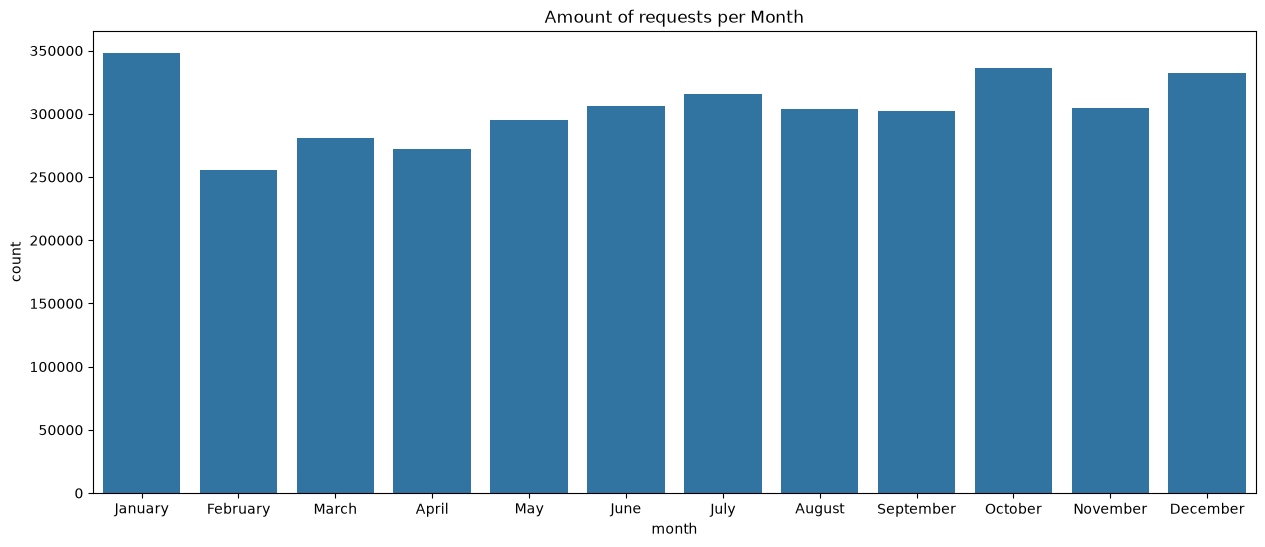

In [121]:
import matplotlib.pyplot as plt

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(15, 6))
plt.title("Amount of requests per Month")
sns.countplot(data=df, x='month', order=month_order)

<Axes: title={'center': 'Amount of requests per day of the week'}, xlabel='week_day', ylabel='count'>

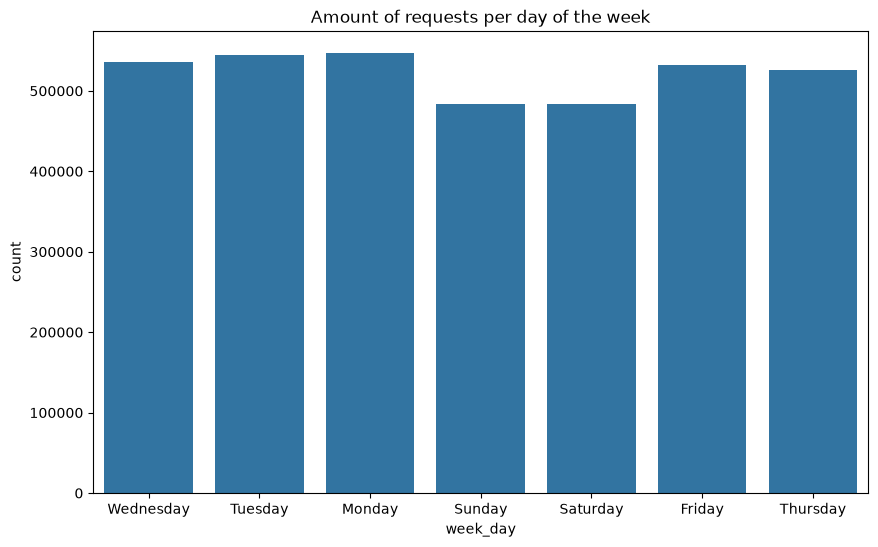

In [122]:
df['week_day'] = df['created_date'].dt.day_name()
plt.figure(figsize=(10, 6))
plt.title("Amount of requests per day of the week")
sns.countplot(data=df, x='week_day')

Its possible to notice that January has a higher peak of requests with a big drop following the next months, and that (Saturday and Sunday) have less requests. to the second insight its possible that the reason is, since more people tend to stay at home during those days, consequently they have a smaller chance of making a request. But for the monthly insight, i dont know the reason so lets look into deeper.


In [125]:
#top 5 most complaint values in the month of january normaliazed to 30 days.
total_days_in_period = 31
((df[df['month'] == 'January']['complaint_type'].value_counts()[:5]) / 31) * 30

complaint_type
Noise - Residential     68551.935484
HEAT/HOT WATER          65060.322581
Illegal Parking         41747.419355
Blocked Driveway        14188.064516
UNSANITARY CONDITION     9677.419355
Name: count, dtype: float64

In [126]:
#top 5 most complaint values in the month of february, mach and april, on average and normaliazed to 30 days.
total_days_in_period = 89
(df[df['month'].isin(['Februrary', 'March', 'April'])]['complaint_type'].value_counts()[:5] / total_days_in_period) * 30

complaint_type
Illegal Parking            34077.977528
Noise - Residential        19169.325843
HEAT/HOT WATER             14528.089888
Blocked Driveway            9138.202247
Noise - Street/Sidewalk     7361.460674
Name: count, dtype: float64

Its noticeable that the amount of complaints about Noise in residential areas, and problems with heating systems have a spike on January compared to the average of the 3 following months. I have an hypothesis that this can be caused by the new years/ vacations parties and heavy winter.

<Axes: title={'center': 'Amount of Noise - Residential complaints per day in January 2025'}, xlabel='day', ylabel='count'>

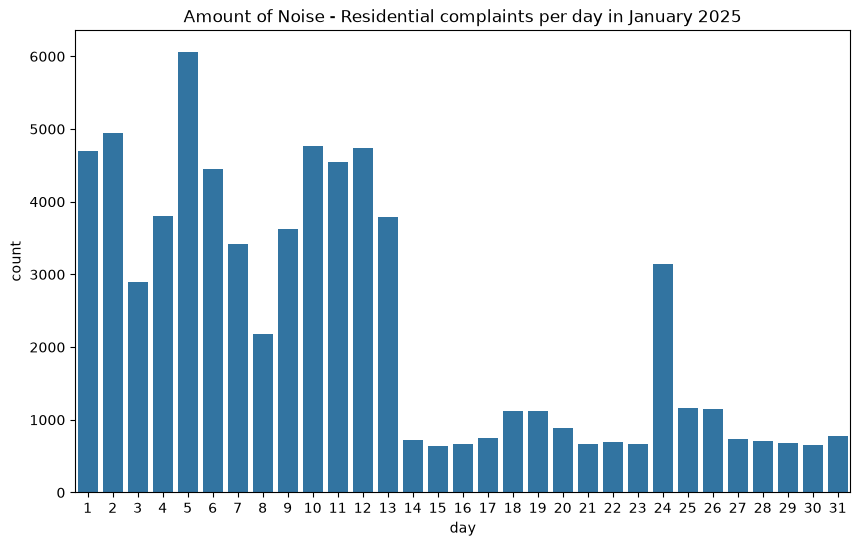

In [127]:
df['day'] = df['created_date'].dt.day
plt.figure(figsize=(10, 6))
plt.title("Amount of Noise - Residential complaints per day in January 2025")
sns.countplot(data=df, x=df[(df['month'] == 'January') & (df['complaint_type'] == 'Noise - Residential')]['day'])

January noise complaints are elevated across roughly the first third of the month, with also a clear spike on day 24, not just around New Year's, so a simple 'holiday parties' explanation doesn't fully account for it.